# Deteccio d'opinions - Supervisat
Max Villalba i Biel Sánchez  
_Processament del Llenguatge Humà - GIA_  
___

## Introducció

En aquesta pràctica desenvoluparem un detector d'opinions (positives i negatives) basat en el **Movie Reviews Corpus**. Primer, aplicarem un preprocessament adequat per a aquesta tasca. A continuació, utilitzarem el mètode de **bag of words** amb **CountVectorizer** per transformar les dades en un format que el model pugui processar.

Posteriorment, realitzarem un **grid search** sobre diferents models i paràmetres per seleccionar el que ofereixi la **major precisió** i alhora **minimitzi l’overfitting**.

Un cop seleccionat el model, l’avaluarem i analitzarem els errors més comuns que comet. En la segona part de la pràctica, compararem aquest model supervisat amb un model no supervisat.

In [1]:
# Fem tots els imports que seran necessaris pel codi

import nltk
nltk.download('movie_reviews')
from nltk.corpus import movie_reviews as mr
import random
from sklearn.feature_extraction.text import CountVectorizer
import seaborn as sns
import pandas as pd
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.pipeline import Pipeline

from sklearn.model_selection import GridSearchCV
from sklearn.utils import shuffle

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

import warnings
warnings.filterwarnings("ignore")

from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import textwrap

[nltk_data] Downloading package movie_reviews to
[nltk_data]     C:\Users\bsanc\AppData\Roaming\nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!


## Train i Validation

En aquest apartat definim els **identificadors de textos positius i negatius** per tal de poder realitzar l'**split** més fàcilment. Abans d'executar-lo, apliquem un **shuffle** per evitar problemes derivats de l'ordre original de les dades, tenint en compte que més endavant en farem un altre per barrejar definitivament positius i negatius. 

A continuació, realitzem una divisió **80/20** entre els conjunts de **train** i **validation**. Hem decidit escollir aquestes proporcions perquè considerem que són les més adequades per a la **mida del nostre corpus**. Finalment, ajuntem els textos positius i els negatius en un mateix conjunt per consolidar l'estructura de treball.

In [2]:
pos_ids = mr.fileids('pos')
neg_ids = mr.fileids('neg')

random.seed(42)
random.shuffle(pos_ids)
random.shuffle(neg_ids)

# Separació entre train i val tant per positius com per negatius
train_pos = pos_ids[:800]
val_pos = pos_ids[800:]

train_neg = neg_ids[:800]
val_neg = neg_ids[800:]

train_files = train_pos + train_neg
val_files = val_pos + val_neg

print(f"Entrenament: {len(train_files)} arxius ({len(train_pos)} pos, {len(train_neg)} neg)")
print(f"Validació: {len(val_files)} arxius ({len(val_pos)} pos, {len(val_neg)} neg)")

Entrenament: 1600 arxius (800 pos, 800 neg)
Validació: 400 arxius (200 pos, 200 neg)


## Preprocessament

En aquest apartat definim el preprocessament que rebran els textos abans de ser introduïts als models. El primer pas consisteix a agafar els textos en brut (**raw**) i crear els vectors **y**, on **1** representa l'opinió positiva i **0** representa una opinió negativa. A continuació, apliquem el **shuffle** que havíem mencionat anteriorment per barrejar els textos positius i negatius, i executem el preprocessament amb **CountVectorizer**. 

**CountVectorizer** té un paràmetre anomenat **max_features** el qual descriu la mida del diccionari amb el qual treballarem (bàsicament el nombre de columnes de la matriu que passarem al predictor). Per escollir el millor valor d'aquest hiperparàmetre hem decidit fer un explorat exhaustiu amb diversos valors i anar analitzant quina era l'accuracy obtinguda amb un model que fos senzill i ràpid (Hem escollit el **Naive Bayes**, ja que compleix totes dues característiques), el **pipeline** prova tots els valors que es veuen al vector i fa un total de 5 repeticions per cada valor per a saber la variància de cada un d'ells.

En la següent secció explicarem quin valor de **max_features** fem servir i el justificarem així com explicarem el preprocessat que fem a partir de **CountVectorizer**.

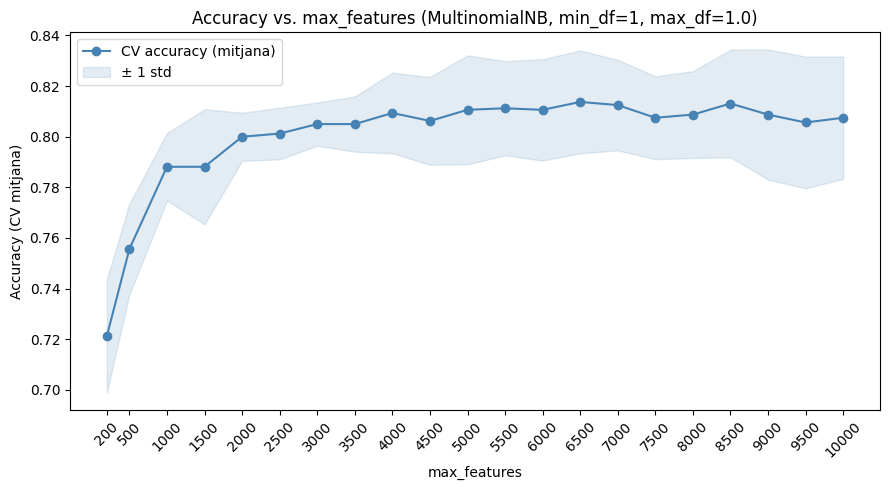

In [3]:
# Dades
train_texts = [mr.raw(fileid) for fileid in train_files]
val_texts = [mr.raw(fileid) for fileid in val_files]

y_train = [1] * 800 + [0] * 800
y_val = [1] * 200 + [0] * 200

train_texts, y_train = shuffle(train_texts, y_train, random_state=42)
val_texts, y_val = shuffle(val_texts, y_val, random_state=42)

# Pipeline i GridSearch només sobre max_features
pipeline_nb = Pipeline([
    ('vec', CountVectorizer(stop_words='english', token_pattern=r'(?u)\b[a-zA-Z]{2,}\b')),
    ('clf', MultinomialNB())
])

param_grid_vec = {
    'vec__max_features': [200, 500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000, 5500, 6000,6500, 7000,7500, 8000,8500, 9000,9500, 10000]
}

grid_vec = GridSearchCV(pipeline_nb, param_grid_vec, cv=5, scoring='accuracy', n_jobs=-1)
grid_vec.fit(train_texts, y_train)


best_nb_model = grid_vec.best_estimator_
train_acc_nb = best_nb_model.score(train_texts, y_train)
val_acc_nb = best_nb_model.score(val_texts, y_val)

results = pd.DataFrame(grid_vec.cv_results_)
x_vals = results['param_vec__max_features'].astype(int).values
y_vals = results['mean_test_score'].values

d2 = np.diff(y_vals, 2)
elbow_idx = np.argmax(d2) + 1 
elbow_x = x_vals[elbow_idx]
elbow_y = y_vals[elbow_idx]

# Gràfica
plt.figure(figsize=(9, 5))
plt.plot(
    x_vals,
    y_vals,
    marker='o',
    color='steelblue',
    label='CV accuracy (mitjana)'
)
plt.fill_between(
    x_vals,
    y_vals - results['std_test_score'].values,
    y_vals + results['std_test_score'].values,
    alpha=0.15,
    color='steelblue',
    label='± 1 std'
)
plt.xlabel('max_features')
plt.ylabel('Accuracy (CV mitjana)')
plt.title('Accuracy vs. max_features (MultinomialNB, min_df=1, max_df=1.0)')
plt.xticks(x_vals, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()



## CountVectorizer

A la gràfica anterior es pot veure clarament com, a partir de les **2000 features**, sembla estabilitzar-se en un accuracy de **0.8**. Tot i això, hem decidit escollir unes **4000 features**, ja que sembla que hi ha un petit salt de millora respecte a les anteriors, i és a partir d’aquest punt on també el rang de confiança comença a augmentar molt, cosa que ens indica que molt possiblement, a partir d’aquest punt, hi haurà **overfitting**. Per tant, tot i que altres punts més endavant sembla que tinguin major accuracy, molt probablement, en provar-ho amb un nou conjunt de dades, es comporti pitjor degut al fet que presentaran aquest problema.

A part d’això, també li passem al **CountVectorizer** dos hiperparàmetres més: **stop_words** i **token_pattern**. El primer serveix per eliminar les **stop words** que estan en anglès (determinants, articles, etc.), ja que considerem que aquestes paraules aporten poca informació. Com que estem treballant amb un màxim de 4000 paraules diferents (**max_features**), preferim centrar-nos en altres que puguin ser més importants. El segon hiperparàmetre fa un filtratge de paraules i elimina les paraules de longitud inferior a dos (per eliminar algun error i coses així) i els **digits**, ja que ens vam fixar que la majoria eren anys i aquests aporten poca informació. Sí que es podria argumentar que alguns digits podrien aportar informació respecte a la nota que es pot donar a una pel·lícula, però la majoria d’aquests estan escrits amb text del tipus ('five stars' o 'nine out of ten').

Finalment, **CountVectorizer**, per si sol, ja passa tots els caràcters a minúscula i elimina els signes de puntuació. Així doncs, amb el preprocessat ja definit, obtenim la matriu que passarem als models en la següent secció.

In [4]:
# Vectoritzador final
best_max_features = 4000

vectorizer = CountVectorizer(
    stop_words='english',
    token_pattern=r'(?u)\b[a-zA-Z]{2,}\b',
    max_features=best_max_features,
)

X_train = vectorizer.fit_transform(train_texts)
X_val = vectorizer.transform(val_texts)
print(f"Shape final de X_train: {X_train.shape}")

Shape final de X_train: (1600, 4000)


## Models i selecció d'hiperparàmetres

Hem definit un conjunt de quatre models diferents per realitzar les prediccions i determinar quin ofereix millors resultats. Els models seleccionats són: **Multinomial Naive Bayes**, **Regressió Logística**, **LinearSVC** i el **Perceptró**.

### Multinomial Naive Bayes
Aquest model és especialment eficaç quan es treballa amb el **Bag of Words** de CountVectorizer, ja que és molt ràpid i gestiona bé les **matrius sparse**. En el nostre cas, disposem d'una columna per cada paraula, fet que genera una matriu amb molts zeros perquè cada text només conté una petita part del vocabulari total. Per a la cerca d'hiperparàmetres, hem explorat diferents valors d'**alpha** (que actua com el suavitzat de Lidstone) i el **fit_prior** per decidir si les probabilitats de les classes han de ser uniformes o basades en l'entrenament.

### Regressió Logística
És un model ideal per a la classificació binària com la que ens ocupa. Per treballar correctament amb matrius sparse, hem seleccionat solvers específics compatibles. Com a hiperparàmetres, definim el paràmetre de regularització **C**, el tipus de **penalty** i el propi **solver**. També hem ajustat el nombre màxim d'iteracions per garantir la convergència del model sense incórrer en **overfitting**.

### SVM Lineal (LinearSVC)
Aquest model és molt eficient en espais de grans dimensions i funciona de manera òptima amb un nombre elevat de paraules. Hem ajustat el paràmetre **C** per controlar la regularització i hem explorat diferents funcions de pèrdua (**loss**). Així mateix, hem analitzat si és més convenient resoldre el problema mitjançant la formulació **dual** o la **primal**, a més de limitar el nombre d'iteracions.

### Perceptró
Similar a l'SVM lineal, el Perceptró és molt adequat per a aquest tipus de dades. Els hiperparàmetres explorats inclouen l'**alpha** (constant de regularització), el **penalty** (L1, L2 o cap), l'**eta0** (velocitat d'aprenentatge) i el nombre màxim d'iteracions. També hem incorporat l'**early stopping** per aturar l'entrenament si el model ja ha convergit.

### Entrenament i avaluació
Un cop definits els models, els entrenem amb el conjunt de **train** i guiem la cerca mitjançant la mètrica d'**accuracy**. Per a cada millor predictor obtingut, realitzem una prova amb el conjunt de **validació** per avaluar el nivell d'overfitting i generem la **matriu de confusió**. En el següent apartat, analitzarem quin és el model escollit i els motius de la decisió.

In [5]:
#Definim els models
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(),
    "Linear SVC": LinearSVC(),
    "Perceptron": Perceptron()
}

param_grids = {
    "Naive Bayes": {
        'alpha': [0.01, 0.1, 0.5, 1.0, 2.0],
        'fit_prior': [True, False]
    },

    "Logistic Regression": {
        'C': [0.001, 0.01, 0.1, 1, 10],
        'penalty': ['l1', 'l2'],
        'solver': ['lbfgs', 'liblinear'],
        'max_iter': [1000, 2000]
    },

    "Linear SVC": {
        'C': [0.001, 0.01, 0.1, 1, 10],
        'loss': ['hinge', 'squared_hinge'],
        'dual': [False, True],
        'max_iter': [1000, 2000, 5000]
    },

    "Perceptron": {
        'alpha': [1e-5, 1e-4, 1e-3, 1e-2],
        'penalty': [None, 'l1', 'l2'],
        'max_iter': [1000, 2000, 5000],
        'eta0': [0.1, 0.01, 0.001],
        'early_stopping': [True, False]
    }
}

# Per cada model, l'entrenem amb el train i escollim el que millor accuracy.

for name, model in models.items():
    print(f"Buscant millors hiperparàmetres per: {name}...")
    
    grid = GridSearchCV(model, param_grids[name], cv=5, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train, y_train)
    
    best_model = grid.best_estimator_
    
    y_pred_val = best_model.predict(X_val)
    y_pred_train = best_model.predict(X_train)
    
    train_acc = accuracy_score(y_train, y_pred_train)
    val_acc = accuracy_score(y_val, y_pred_val)
    
    print(f"--- {name} ---")
    print(f"Millors hiperparàmetres: {grid.best_params_}")
    print(f"Train accuracy: {train_acc:.4f}")
    print(f"Validation accuracy: {val_acc:.4f}")
    print(f"Gap (overfitting): {train_acc - val_acc:.4f}")
    
    print("Matriu de Confusió (validation):")
    print(confusion_matrix(y_val, y_pred_val))
    print("\n")

Buscant millors hiperparàmetres per: Naive Bayes...
--- Naive Bayes ---
Millors hiperparàmetres: {'alpha': 1.0, 'fit_prior': True}
Train accuracy: 0.9038
Validation accuracy: 0.8100
Gap (overfitting): 0.0938
Matriu de Confusió (validation):
[[169  31]
 [ 45 155]]


Buscant millors hiperparàmetres per: Logistic Regression...
--- Logistic Regression ---
Millors hiperparàmetres: {'C': 0.01, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}
Train accuracy: 0.9769
Validation accuracy: 0.8600
Gap (overfitting): 0.1169
Matriu de Confusió (validation):
[[172  28]
 [ 28 172]]


Buscant millors hiperparàmetres per: Linear SVC...
--- Linear SVC ---
Millors hiperparàmetres: {'C': 0.001, 'dual': False, 'loss': 'squared_hinge', 'max_iter': 1000}
Train accuracy: 0.9775
Validation accuracy: 0.8475
Gap (overfitting): 0.1300
Matriu de Confusió (validation):
[[164  36]
 [ 25 175]]


Buscant millors hiperparàmetres per: Perceptron...
--- Perceptron ---
Millors hiperparàmetres: {'alpha': 1e-05, 'early_

## Millor model:

Un cop fet l'entrenament i després de trobar els millors hiperparàmetres per cada model, seleccionarem el millor. Per triar el millor model buscarem aquell resultat que obtingui el millor equilibri entre **poc overfitting** i **accuracy elevada**.

Observant el que hem obtingut, podem veure que **Naive Bayes** tot i ser el model amb menys overfitting, és el que obté l'accuracy més baixa. De manera contraria, tot i que la **linear SVC** i el **perceptró** obtenen una accuracy molt elevada en el train, són els models amb més overfitting, indicant que es sobreajusten molt a les dades d'entrenament.

Es per aixó que triem la **regressió logística** (amb els millors paràmetres trobats), ja és el model que presenta el millor equilibri entre els dos aspectes.

A continuació, tornem a entrenar el model triat per tal d'obtenir els resultats finals i poder continuar amb els següents apartats.

In [6]:
best_model = LogisticRegression(C=0.01, penalty='l2', solver='lbfgs', max_iter=1000)

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_val)

## Anàlisi dels resultats:

Començarem comentant els **resultats obtinguts**.

La matriu de confusió següent ens mostra els valors reals en relació als valors predits pel model. Podem veure que, en general, el model prediu prou bé si una opinió es positiva o negativa, i això es reflexa en que la gran proporció de valors es situen en la diagonal principal.

Únicament en 56 casos el model prediu de manera errònia, fet que estudiarem en el següent apartat d'anàlisi dels errors.

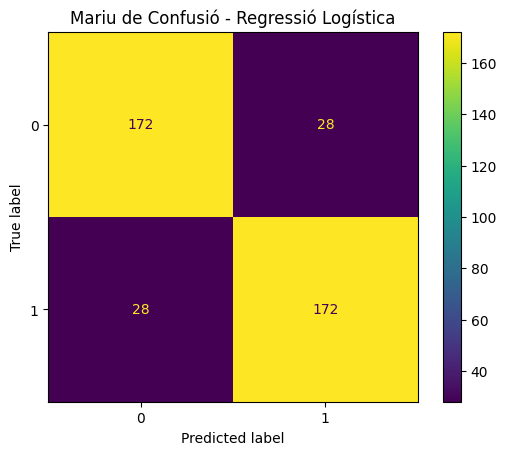

In [7]:
cm = confusion_matrix(y_val, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Mariu de Confusió - Regressió Logística")
plt.show()

Comencem ara a fer un **anàlisi dels errors**, on intentarem veure on i perquè el model falla en certes situacions.

In [8]:
errors = [i for i in range(len(y_val)) if y_val[i] != y_pred[i]]
error_texts = [val_texts[i] for i in errors]

print(f"Total d'errors: {len(errors)}")

fp_indices = [i for i in range(len(y_val)) if y_val[i] == 0 and y_pred[i] == 1]
fn_indices = [i for i in range(len(y_val)) if y_val[i] == 1 and y_pred[i] == 0]

fp_texts = [val_texts[i] for i in fp_indices]
fn_texts = [val_texts[i] for i in fn_indices]


print(f"    Falsos Positius (Real: Negativa, Predicció: Positiva): {len(fp_indices)}")
print(f"    Falsos Negatius (Real: Positiva, Predicció: Negativa): {len(fn_indices)}")

Total d'errors: 56
    Falsos Positius (Real: Negativa, Predicció: Positiva): 28
    Falsos Negatius (Real: Positiva, Predicció: Negativa): 28


Tal i com hem observat en la matriu de confusió, tenim un total de **56 errors**, dels cuals **28 es deuen a falsos positius** (la predicció diu que la opinió és positiva quan en realitat és negativa) i **28 es deuen a falsos negatius** (la predicció diu que la opinió és negativa quan en realitat és positiva).

Podem veure que la proporció de falsos positius i falsos negatius es exactament igual, indicant que el model **no presenta un biaix clar** cap a ninguna de les dues classes i, per tant, comet errors de manera **equilibrada** entre opinions positives i negatives.

A continuació analitzarem quines han sigut les paraules més comunes en els errors.

Començarem fent un anàlisi general:

In [9]:
analyzer = vectorizer.build_analyzer()

# Funció auxiliar per trobar les n paraules més comunes en un text
def get_top_n_words(texts, n):
    words = []
    for text in texts:
        words.extend(analyzer(text))
    return Counter(words).most_common(n)

In [10]:
common_words = get_top_n_words(error_texts, 20)

print("Les 20 paraules més comunes en errors (Paraula => Vegades que apareix):")
for w, c in common_words:
    print(f"{w} => {c}")

Les 20 paraules més comunes en errors (Paraula => Vegades que apareix):
film => 313
movie => 135
like => 80
just => 77
time => 66
good => 63
story => 60
little => 50
films => 48
characters => 46
plot => 46
people => 44
end => 44
love => 43
character => 43
know => 42
scenes => 42
make => 42
man => 41
director => 40


Si observem amb detall les paraules que apareixen més en les opinions mal classificades, podem veure **tres fenòmens diferents**:
- En primer lloc tenim paraules que, degut al context en el que estem treballant, és normal que **apareguin més vegades**. Per exemple, paraules com *film*, *movie* o *story* són paraules que, al estar treballant amb **opinons de pel·licules**, té lògica que apareguin tant en opinions positives com negatives. Per tant, també té sentit que apareguin més vegades que la resta de paraules en els exemples mal classificats.

- En segon lloc ens trobem amb **paraules enganyoses**: paraules que *sembla* que determinin el sentiment d'un text, però que no té perquè. Per exemple, paraules com *good* o *like* podrien fer pensar al model que es tracta d'una opinió positiva, mentre que paraules com *little* podrien fer pensar que és una opinió negativa, i això no és sempre així.

- Per últim, és interessant veure que altres paraules com *time*, *know* o *make* apareixen també en molts textos mal classificats, tot i que no sembla que hi hagi un motiu aparent.

A continuació mirarem un altre cop les paraules més comunes en els errors, però aquesta vegada ho separarem entre **falsos positius** i **falsos negatius**:

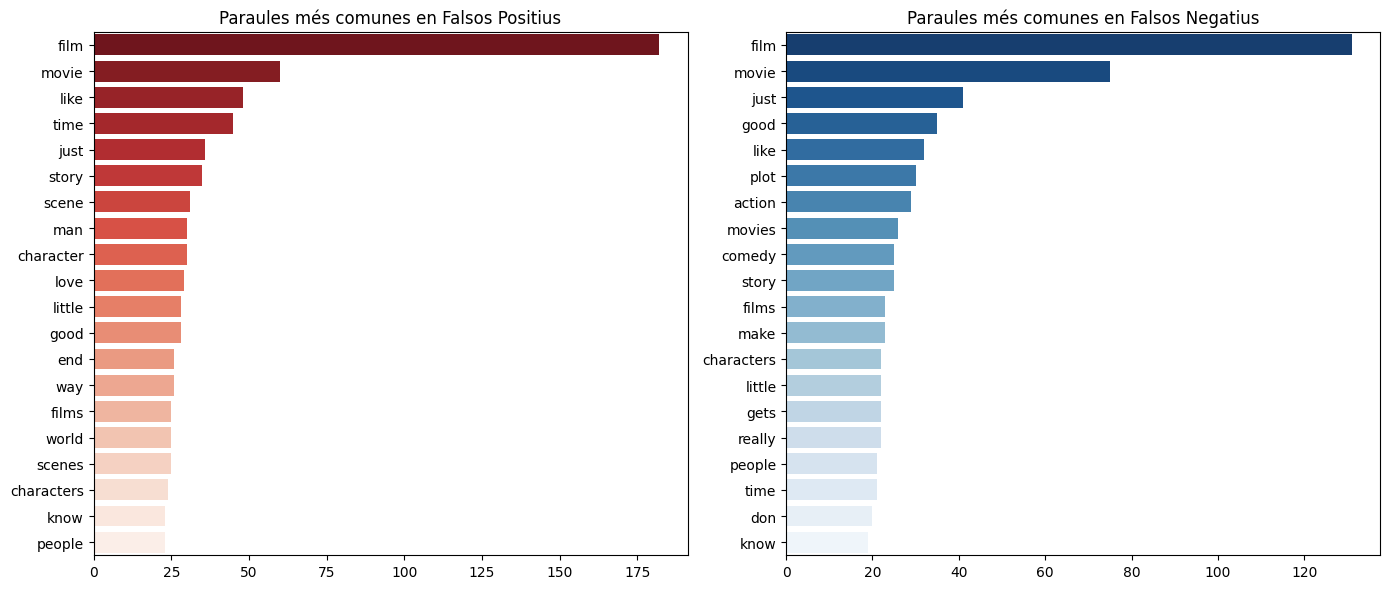

In [11]:
top_fp = get_top_n_words(fp_texts, 20)
top_fn = get_top_n_words(fn_texts, 20)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(x=[c for w, c in top_fp], y=[w for w, c in top_fp], ax=axes[0], palette="Reds_r")
axes[0].set_title("Paraules més comunes en Falsos Positius")

sns.barplot(x=[c for w, c in top_fn], y=[w for w, c in top_fn], ax=axes[1], palette="Blues_r")
axes[1].set_title("Paraules més comunes en Falsos Negatius")

plt.tight_layout()
plt.show()

Podem veure que el patró general tant en falsos positius com en falsos negatius és **molt semblant** entre ells. Es pot observar el mateix fenòmen que teniem abans: paraules com *film* i *movie* apareixen molt sovint en els dos casos.

Curiosament, i a diferència del que semblava en l'anterior apartat, la paraula *good* apareix més cops en els falsos negatius que en els falsos positius. És a dir, quan el model "veu" la paraula *good*, es més probable que la classifiqui com a opinió negativa que com a opinió positiva. Podem observar un cas semblant amb *little*, ja que aquest apareix més cops en els falsos positius que en els falsos negatius. En el cas de la paraula *like*, la tenim força present en els dos casos.

En el següent apartat ens centrarem en la **longitud** dels textos:

Longitud mitjana en errors: 300.91 (Min: 85, Max: 877)
Longitud mitjana en encerts: 323.36 (Min: 57, Max: 1086)


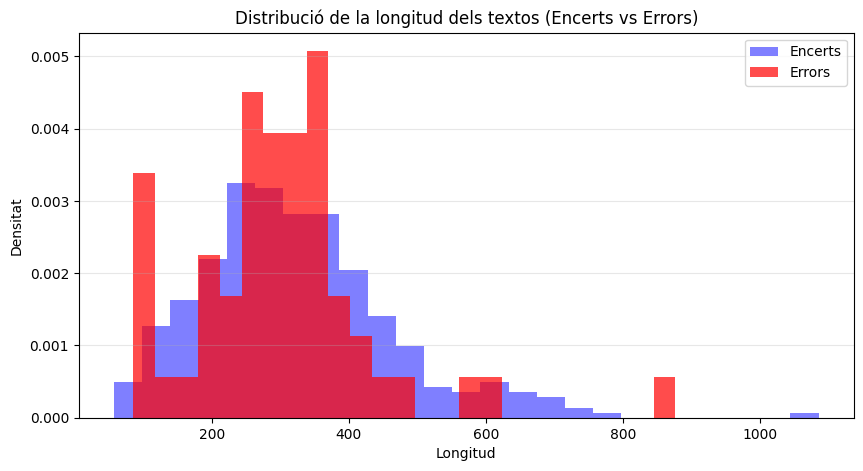

In [12]:
lengths_errors = [len(analyzer(t)) for t in error_texts]
correct_texts = [val_texts[i] for i in range(len(y_val)) if y_val[i] == y_pred[i]]
lengths_correct = [len(analyzer(t)) for t in correct_texts]

print(f"Longitud mitjana en errors: {np.mean(lengths_errors):.2f} (Min: {np.min(lengths_errors)}, Max: {np.max(lengths_errors)})")
print(f"Longitud mitjana en encerts: {np.mean(lengths_correct):.2f} (Min: {np.min(lengths_correct)}, Max: {np.max(lengths_correct)})")

plt.figure(figsize=(10, 5))
plt.hist(lengths_correct, bins=25, alpha=0.5, label='Encerts', color='blue', density=True)
plt.hist(lengths_errors, bins=25, alpha=0.7, label='Errors', color='red', density=True)
plt.title("Distribució de la longitud dels textos (Encerts vs Errors)")
plt.xlabel("Longitud")
plt.ylabel("Densitat")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

Si mirem el gràfic podem veure que els errors s'ubiquen principalment en **longituds petites**, mentre que els encerts, tot i estar presents en moltes longituds, hi ha una proporció important d'aquests situats en **longituds força grans**. Això indica que, en general, el model sol classificar correctament les opinions llargues mentre que sol fallar les opinions curtes, ja que no té tant "context" per determinar si una opinió és positiva o negativa.

Es interessant veure com en el cas del errors hi ha un fort pic en les **longituds més petites** i la majoria dels valors es situen en una zona al voltant de *longitud = 320* força **concentrada**, mentre que la distribució dels encerts és més **suau** i **repartida**.

Per acabar, anem a mirar alguns exemples d'opinions classificades incorrectament. Agafarem 5 exemples per simplificar:

In [13]:
for i in errors[:5]:
    real_label = "Positiva" if y_val[i] == 1 else "Negativa"
    pred_label = "Positiva" if y_pred[i] == 1 else "Negativa"
    error_type = "Fals Negatiu" if y_val[i] == 1 else "Falso Positiu"
    
    print(f"{error_type} (Real: {real_label} | Predicció: {pred_label})")
    print("-" * 50)
    # Mostrem els primers 300 caràcters
    print(textwrap.fill(val_texts[i][:300] + "...", width=80))
    print("=" * 50)

Fals Negatiu (Real: Positiva | Predicció: Negativa)
--------------------------------------------------
notice : this is a review and analysis of exotica .  the first part of this
piece is the review , the second part contains some analysis of the movie which
might be construed as spoilers .  if you have not seen the movie and after
reading the first part you intend to do so , then save the second par...
Fals Negatiu (Real: Positiva | Predicció: Negativa)
--------------------------------------------------
jacques tati's 1953 classic " les vacances de m . hulot " ( also known as " mr .
hulot's vacation , " in english ) ought to be the textbook on how to do non ?
dialogue comedy in film .  the characters hardly ever speak to each other
directly , and the film operates on the paper ? thin premise that m...
Falso Positiu (Real: Negativa | Predicció: Positiva)
--------------------------------------------------
'traffic violation' dr . daniel's review of u-turn  dr . d's rating : critical
con

Analitzant els exemples podem veure una gran varietat de casos:
- En general, les opinions positives classificades incorrectament com a negatives mostren la presencia de parts **expresades en "negatiu"**: com per exemple "*if you have not seen the movie...*", "*the characters hardly ever speak to each other directly...*" o "*however , what lies inside this nominally safe atmosphere is a " strange world ..."*". Aquestes expressions poden fer dubtar al model resultant en una incorrecta classificació.

- Pel cas de les opinions negatives classificades incorrectament com a positives, podem veure que de manera semblant hi ha parts del text que poden fer que el model predigui positiu malament, com per exemple "*necessary part of doing any job well...*". Altres textos, com l'últim exemple mostrat, curiosament és classificat com a positiu tot i ser clarament negatiu. Potser l'ús d'adjectius de manera continuada fa que el model es pensi que la opinió és positiva.

# Deteccio d'opinions - No Supervisat
Max Villalba i Biel Sánchez  
_Processament del Llenguatge Humà - GIA_  
___

## UKB vs Lesk

Abans de començar amb el model, hem de decidir quin mètode de desambiguació dels sentits **(WSD)** farem servir. Compararem **Lesk** i **UKB** per veure quin dels dos dona millors resultats.

### UKB

Començarem per UKB, en aquesta secció farem WSD d'una frase del corpus per tal de veure quins resultats dona i poder analitzar que tan acurat és.

In [ ]:
# Inicialitzem Textserver
from textserver import TextServer
ts = TextServer('user', 'passwd', 'senses') 

In [7]:
# Seleccionem per exemple el primer text dels positius
pos_ids = mr.fileids('pos')
train_p = [mr.raw(fileid) for fileid in pos_ids[:5]]
print(train_p)

['films adapted from comic books have had plenty of success , whether they\'re about superheroes ( batman , superman , spawn ) , or geared toward kids ( casper ) or the arthouse crowd ( ghost world ) , but there\'s never really been a comic book like from hell before . \nfor starters , it was created by alan moore ( and eddie campbell ) , who brought the medium to a whole new level in the mid \'80s with a 12-part series called the watchmen . \nto say moore and campbell thoroughly researched the subject of jack the ripper would be like saying michael jackson is starting to look a little odd . \nthe book ( or " graphic novel , " if you will ) is over 500 pages long and includes nearly 30 more that consist of nothing but footnotes . \nin other words , don\'t dismiss this film because of its source . \nif you can get past the whole comic book thing , you might find another stumbling block in from hell\'s directors , albert and allen hughes . \ngetting the hughes brothers to direct this see

In [9]:
# Seleccionem la primera frase amb el format correcte
from nltk.tokenize import sent_tokenize
text = train_p[0]
frases = sent_tokenize(text)
primera_frase = frases[0]
print(primera_frase)

films adapted from comic books have had plenty of success , whether they're about superheroes ( batman , superman , spawn ) , or geared toward kids ( casper ) or the arthouse crowd ( ghost world ) , but there's never really been a comic book like from hell before .


In [ ]:
#Cridem a textserver per a crear el df amb el synset, de moment no l'imprimim per pantalla ja que volem afegir alguna columna més.
df = ts.senses(primera_frase, pandas=True)

In [ ]:
# Funció per obtenir el synset de wordnet
from nltk.corpus import wordnet as wn
import pandas as pd

def convert_synset_safe(s):
    if pd.isna(s):        # Ignora NA
        return None
    try:
        offset, pos = s.split('-')   # "123-n" -> ["123", "n"]
        return wn.synset_from_pos_and_offset(pos, int(offset))
    except:
        return None  # Si hi ha algun error, també retorna None

# Aplica la funció a la columna
df['synset_obj'] = df['synset'].apply(convert_synset_safe)

In [ ]:
# Funció per obtenir la definició
def get_definition(syn):
    if syn is None:    # Ignora les files NA
        return None
    return syn.definition()

# Afegeix la columna amb les definicions
df['definition'] = df['synset_obj'].apply(get_definition)

df

,forma,lema,tag,pos,synset,synset_obj,definition
0,films,film,NNS,noun,06613686-n,Synset('movie.n.01'),a form of entertainment that enacts a story by...
1,adapted,adapt,VBD,verb,00299580-v,Synset('adapt.v.01'),"make fit for, or change to suit a new purpose"
2,from,from,IN,preposition,N/A,None,None
3,comic,comic,JJ,adjective,01265308-a,Synset('amusing.s.02'),arousing or provoking laughter
4,books,book,NNS,noun,02870092-n,Synset('book.n.02'),physical objects consisting of a number of pag...
5,have,have,VBP,verb,00065639-v,Synset('suffer.v.02'),undergo (as of injuries and illnesses)
6,had,have,VBD,verb,00065639-v,Synset('suffer.v.02'),undergo (as of injuries and illnesses)
7,plenty_of,plenty_of,DT,determiner,N/A,None,None
8,success,success,NN,noun,00063652-n,Synset('success.n.02'),an attainment that is successful
9,",",",",Fc,punctuation,N/A,None,None


### Lesk

A continuació, farem el mateix amb Lesk i compararem els resultats obtinguts amb els de UKB.

In [10]:
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\maxvi\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\maxvi\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [17]:
pos_files = mr.fileids('pos')

pos_sents = [mr.sents(pos_files[0])[0]]

def desambigua_frase(frase, i):
    for paraula in frase:
        synset = nltk.wsd.lesk(frase, paraula)
        if synset:
            print(f"  {paraula}: {synset.name()} ({synset.definition()})")
        else:
            print(f"  {paraula}: N/A")

frase = pos_sents[0]
desambigua_frase(frase, 1)



  films: movie.n.01 (a form of entertainment that enacts a story by sound and a sequence of images giving the illusion of continuous movement)
  adapted: adapt.v.01 (make fit for, or change to suit a new purpose)
  from: N/A
  comic: comic.a.02 (of or relating to or characteristic of comedy)
  books: record.n.05 (a compilation of the known facts regarding something or someone)
  have: have.v.01 (have or possess, either in a concrete or an abstract sense)
  had: have.v.01 (have or possess, either in a concrete or an abstract sense)
  plenty: batch.n.02 ((often followed by `of') a large number or amount or extent)
  of: N/A
  success: success.n.03 (a state of prosperity or fame)
  ,: N/A
  whether: N/A
  they: N/A
  ': N/A
  re: ra.n.02 (ancient Egyptian sun god with the head of a hawk; a universal creator; he merged with the god Amen as Amen-Ra to become the king of the gods)
  about: about.r.07 ((of actions or states) slightly short of or not quite accomplished; all but)
  superheroes:

Tal com es pot veure, tant **Lesk** com **UKB** donen resultats bastant similars, ja que tots dos cometen certs errors. Per exemple, observem que ambdós fallen en paraules com **batman** o **superman**, ja que són mots que probablement no es troben a **WordNet**. També es poden observar altres detalls més curiosos: per exemple, **Lesk** sembla fallar sovint amb paraules de longitud molt curta com **a** o **or**, ja que en alguns casos no les detecta correctament, mentre que **UKB** sembla cometre alguns errors amb paraules que poden actuar com a noms o adjectius, com ara **comic** o **spawn**. A més, cal destacar que tots dos mètodes presenten casos amb resultat **N/A**, de manera que aquest aspecte no és un factor diferencial entre ells.

Hem decidit escollir **Lesk** perquè considerem que és lleugerament més fiable en el tractament de paraules com noms i adjectius, fet que resulta especialment útil a l’hora de fer anàlisi de sentiments. A més, **Lesk** és molt més ràpid i eficient que **UKB** quan es treballa amb textos llargs —que són precisament els que utilitzarem—, ja que no disposem d’accés local a **UKB** i hem de fer crides a un servidor extern. Aquest fet pot provocar errors o limitacions quan el text és massa extens.

In [29]:
#Cel·la per fer tots els imports de la part b

import nltk
from nltk import word_tokenize, pos_tag
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
nltk.download("punkt")
nltk.download("averaged_perceptron_tagger")
nltk.download("wordnet")
nltk.download("omw-1.4")

from nltk.corpus import sentiwordnet as swn
import nltk

nltk.download("sentiwordnet")

lemmatizer = WordNetLemmatizer()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)
from collections import Counter

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\bsanc\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\bsanc\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\bsanc\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\bsanc\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package sentiwordnet to
[nltk_data]     C:\Users\bsanc\AppData\Roaming\nltk_data...
[nltk_data]   Package sentiwordnet is already up-to-date!


## Preprocessat

Per tal de poder treballar amb **Lesk**, primer hem de dur a terme el preprocessat. Aquest es distribuirà en tres parts: la primera serà la **tokenització**, és a dir, separar cada text en paraules. A continuació aplicarem la **lematització** per tal d'obtenir el lema de cada mot, ja que és un requisit per aplicar **Lesk**. Finalment, aplicarem també **POS Tagging** ja que **Lesk** necessita saber si una paraula és adjectiu, nom, verb, etc. D'aquesta manera podrem passar aquestes dades a **Lesk** i s'encarregarà de fer la WSD. A més, també eliminem la puntuació i els digits, tal com vam fer en l'apartat supervisat.

En la següent cel·la duguem a terme tot això a partir de la funció **preprocess_text**, que s'encarrega d'obtenir els tokens i els **POS tags** de cada mot per tal de, després, poder obtenir els lemes. Finalment, ens retorna una llista de llistes, on cada una d'elles és una frase separada per cada lema amb el seu **POS tag**.

In [16]:
# Transformar els POS Tags al format de WordNet
def penn_to_wordnet(tag):
    if tag.startswith("J"):
        return wordnet.ADJ
    if tag.startswith("V"):
        return wordnet.VERB
    if tag.startswith("N"):
        return wordnet.NOUN
    if tag.startswith("R"):
        return wordnet.ADV
    return wordnet.NOUN  

def preprocess_text(text):
    tokens = word_tokenize(text)
    tagged = pos_tag(tokens)  # [(token, POS), ...]
    
    # deixem només paraules alfabètiques (fora puntuació i números)
    tagged = [(w.lower(), t) for w, t in tagged if w.isalpha()]
    
    # lematització condicionada pel POS
    lemmas_with_pos = []
    for w, t in tagged:
        wn_pos = penn_to_wordnet(t)
        lemma = lemmatizer.lemmatize(w, pos=wn_pos)
        lemmas_with_pos.append((lemma, t))  # lema + POS original Penn
    return lemmas_with_pos

# Resultat per a tots els textos de validació
val_processed = [preprocess_text(text) for text in val_texts]

# Exemple d'inspecció del primer text
print(val_processed[0][:25])

[('hav', 'NN'), ('plenty', 'NN'), ('a', 'IN'), ('we', 'PRP'), ('be', 'VBP'), ('tell', 'VBN'), ('in', 'IN'), ('the', 'DT'), ('beginning', 'NN'), ('and', 'CC'), ('remind', 'VBD'), ('during', 'IN'), ('the', 'DT'), ('film', 'NN'), ('be', 'VBZ'), ('a', 'DT'), ('true', 'JJ'), ('story', 'NN'), ('life', 'NN'), ('itself', 'PRP'), ('be', 'VBZ'), ('a', 'DT'), ('series', 'NN'), ('of', 'IN'), ('true', 'JJ')]


A continuació, cal decidir quin conjunt de categories gramaticals farem servir: només **adjectius**, **adjectius + adverbis + noms** o **adjectius + adverbis + noms + verbs**. Com que no ens semblava una decisió immediata ni trivial, hem decidit continuar amb totes tres opcions inicialment i recollir els resultats per cadascuna. D’aquesta manera, podrem analitzar posteriorment quina combinació proporciona millor **accuracy** i, a partir d’aquesta anàlisi, escollir la més adequada per al nostre model. Aquest enfocament ens permet evitar prendre una decisió important de manera precipitada, sense tenir dades objectives que ens indiquin quina és la millor opció, i alhora ens proporciona informació útil sobre com cada tipus de paraula contribueix a l’anàlisi de sentiments.

In [17]:
# Funció genèrica per filtrar per categories POS 
def filter_by_pos(val_processed, allowed_initials):
    return [
        [(lemma, pos) for lemma, pos in doc if pos.startswith(allowed_initials)]
        for doc in val_processed
    ]

# 1) Només adjectius
val_adj = filter_by_pos(val_processed, ("J",))          # JJ, JJR, JJS

# 2) Noms + adjectius + adverbis
val_nar = filter_by_pos(val_processed, ("N", "J", "R")) # NN*, JJ*, RB*

# 3) Noms + adjectius + verbs + adverbis
val_njvr = filter_by_pos(val_processed, ("N", "J", "V", "R"))

# Exemple
print(val_adj[0])
print(val_nar[0])
print(val_njvr[0])

[('true', 'JJ'), ('true', 'JJ'), ('most', 'JJS'), ('scripted', 'JJ'), ('cinematic', 'JJ'), ('hav', 'JJ'), ('best', 'JJS'), ('stilted', 'JJ'), ('content', 'JJ'), ('much', 'JJ'), ('lee', 'JJ'), ('new', 'JJ'), ('various', 'JJ'), ('single', 'JJ'), ('married', 'JJ'), ('tammi', 'JJ'), ('hav', 'JJ'), ('chenoa', 'JJ'), ('picky', 'JJ'), ('sexy', 'JJ'), ('trite', 'JJ'), ('cute', 'JJ'), ('wealthy', 'JJ'), ('close', 'JJS'), ('hav', 'JJ'), ('new', 'JJ'), ('bad', 'JJR'), ('outrageous', 'JJ'), ('true', 'JJ'), ('hav', 'JJ'), ('outrageous', 'JJ'), ('least', 'JJS'), ('interesting', 'JJ'), ('hav', 'JJ'), ('much', 'JJ'), ('bad', 'JJ'), ('total', 'JJ'), ('hav', 'JJ'), ('fine', 'JJ'), ('most', 'JJS')]
[('hav', 'NN'), ('plenty', 'NN'), ('beginning', 'NN'), ('film', 'NN'), ('true', 'JJ'), ('story', 'NN'), ('life', 'NN'), ('series', 'NN'), ('true', 'JJ'), ('story', 'NNS'), ('most', 'JJS'), ('not', 'RB'), ('movie', 'NN'), ('material', 'NN'), ('scripted', 'JJ'), ('cinematic', 'JJ'), ('newcomer', 'NN'), ('christo

## Word Sense Desambiguation (WSD)

En la següent secció continuem amb el **WSD** amb **Lesk**. És un apartat més aviat senzill, ja que l’únic que fem és crear una funció que, per a cada mot de cada frase, crida a **Lesk** i obté el **synset** corresponent segons el **lema**, el seu **POS Tag** i el **context**, que són els lemes del mateix text. Fem servir el mètode de **Lesk** simplificat, ja que segons el vist a classe de teoria, dóna millors resultats que el mètode original.

Com a nota, si no obtenim cap resultat el marquem com a **None** i més endavant l’ignorarem, ja que considerem que si **Lesk** no el troba, la paraula no aporta informació rellevant i qualsevol decisió de substituir-lo per algun **synset** similar podria aportar **soroll**.

In [18]:
def lesk_disambiguate_docs(docs):
    all_docs_synsets = []
    for doc in docs:
    # context per Lesk: els lemes del mateix text
        context = [lemma for lemma, _ in doc]
        doc_out = []

        for lemma, penn_pos in doc:
            wn_pos = penn_to_wordnet(penn_pos)
            syn = nltk.wsd.lesk(context, lemma, pos=wn_pos) if wn_pos else None
            # guardem synset object (o None)
            doc_out.append((lemma, penn_pos, syn))

        all_docs_synsets.append(doc_out)

    return all_docs_synsets

val_adj_synsets = lesk_disambiguate_docs(val_adj)
val_nar_synsets = lesk_disambiguate_docs(val_nar)
val_njvr_synsets = lesk_disambiguate_docs(val_njvr)

# Exemple 
print(val_adj_synsets[0])
print(val_nar_synsets[0])
print(val_njvr_synsets[0])

[('true', 'JJ', Synset('true.a.01')), ('true', 'JJ', Synset('true.a.01')), ('most', 'JJS', Synset('most.a.01')), ('scripted', 'JJ', Synset('scripted.a.01')), ('cinematic', 'JJ', Synset('cinematic.a.01')), ('hav', 'JJ', None), ('best', 'JJS', Synset('best.a.01')), ('stilted', 'JJ', None), ('content', 'JJ', Synset('contented.a.01')), ('much', 'JJ', Synset('much.a.01')), ('lee', 'JJ', None), ('new', 'JJ', Synset('new.a.01')), ('various', 'JJ', None), ('single', 'JJ', Synset('individual.a.01')), ('married', 'JJ', Synset('married.a.01')), ('tammi', 'JJ', None), ('hav', 'JJ', None), ('chenoa', 'JJ', None), ('picky', 'JJ', None), ('sexy', 'JJ', Synset('sexy.a.01')), ('trite', 'JJ', None), ('cute', 'JJ', None), ('wealthy', 'JJ', None), ('close', 'JJS', Synset('close.a.02')), ('hav', 'JJ', None), ('new', 'JJ', Synset('new.a.01')), ('bad', 'JJR', Synset('bad.a.01')), ('outrageous', 'JJ', None), ('true', 'JJ', Synset('true.a.01')), ('hav', 'JJ', None), ('outrageous', 'JJ', None), ('least', 'JJS',

## SentiWordNet

Un cop hem obtingut els **synsets** amb **Lesk**, procedim amb **SentiWordNet**. Aquí el procediment també és senzill: per cada **synset** obtingut amb **Lesk**, el busquem a **SentiWordNet** i aquest ens retorna el seu valor **positiu**, **negatiu** i **objectiu**, els quals sumen 1 entre si.

Com hem mencionat abans, en el cas que algun **synset** de **Lesk** sigui **N/A**, o bé si no es troba algun **synset** a **SentiWordNet**, l’ignorarem, ja que no podem fer cap assumció sobre aquest i escollir-ne algun de similar podria aportar **soroll** al model. A més, si algun **synset** no es troba, és perquè molt probablement sigui molt específic o algun nom comú que no aportarà cap mena d’informació al model.

In [19]:
def add_swn_scores(docs_with_synsets):
    """
    docs_with_synsets: [[(lemma, penn_pos, synset_or_none), ...], ...]
    retorna: [[(lemma, penn_pos, synset_name, pos_score, neg_score, obj_score), ...], ...]
    """
    docs_out = []

    for doc in docs_with_synsets:
        doc_out = []

        for lemma, penn_pos, syn in doc:
            if syn is None:
                continue  # si no hi ha synset, ignora

            try:
                ss = swn.senti_synset(syn.name())  # pot fallar si no existeix a SWN
                doc_out.append(
                    (lemma, penn_pos, syn.name(), ss.pos_score(), ss.neg_score(), ss.obj_score())
                )
            except Exception:
                continue  # si no existeix a SentiWordNet, ignora

        docs_out.append(doc_out)

    return docs_out

# Scores per als 3 conjunts
val_adj_swn = add_swn_scores(val_adj_synsets)
val_nar_swn = add_swn_scores(val_nar_synsets)
val_njvr_swn = add_swn_scores(val_njvr_synsets)

# Exemple
print(val_adj_swn[0])
print(val_nar_swn[0])
print(val_njvr_swn[0])

[('true', 'JJ', 'true.a.01', 0.5, 0.375, 0.125), ('true', 'JJ', 'true.a.01', 0.5, 0.375, 0.125), ('most', 'JJS', 'most.a.01', 0.0, 0.0, 1.0), ('scripted', 'JJ', 'scripted.a.01', 0.0, 0.0, 1.0), ('cinematic', 'JJ', 'cinematic.a.01', 0.0, 0.0, 1.0), ('best', 'JJS', 'best.a.01', 0.75, 0.0, 0.25), ('content', 'JJ', 'contented.a.01', 0.0, 0.0, 1.0), ('much', 'JJ', 'much.a.01', 0.0, 0.0, 1.0), ('new', 'JJ', 'new.a.01', 0.375, 0.0, 0.625), ('single', 'JJ', 'individual.a.01', 0.0, 0.0, 1.0), ('married', 'JJ', 'married.a.01', 0.0, 0.0, 1.0), ('sexy', 'JJ', 'sexy.a.01', 0.625, 0.0, 0.375), ('close', 'JJS', 'close.a.02', 0.375, 0.0, 0.625), ('new', 'JJ', 'new.a.01', 0.375, 0.0, 0.625), ('bad', 'JJR', 'bad.a.01', 0.0, 0.625, 0.375), ('true', 'JJ', 'true.a.01', 0.5, 0.375, 0.125), ('least', 'JJS', 'least.a.01', 0.0, 0.0, 1.0), ('interesting', 'JJ', 'interesting.a.01', 0.375, 0.0, 0.625), ('much', 'JJ', 'much.a.01', 0.0, 0.0, 1.0), ('bad', 'JJ', 'bad.a.01', 0.0, 0.625, 0.375), ('fine', 'JJ', 'fine.a

## Càlcul del score

Un cop tenim els valors obtinguts a través del **SentiWordNet**, procedim a fer el càlcul de l’**score**. Aquest s’ha definit de la següent manera per a un **synset** qualsevol:

```python
score = score_pos - score_neg
```

D’aquesta manera podem detectar molt ràpidament la polaritat d’una paraula: si té un valor positiu, serà una paraula **positiva**, i si el valor és negatiu, serà **negativa**. A més, com més gran sigui el valor absolut de l’**score**, més segurs estem sobre la polaritat de la paraula.

Per calcular l’**score** de cada text, senzillament sumem l’**score** de cada paraula i així obtenim el resultat per a cada text: si la majoria de paraules són **positives** o bé el text conté paraules de les quals la seguretat de les positives és major que la seguretat de les que són negatives, considerem que la ressenya és **positiva** i viceversa.

En la següent cel·la es defineixen les funcions per calcular l’**score** individualment i per cada text.

In [20]:
# Funció per a calcular l'score de cada synset
def doc_sentiment_score(doc):
    total = 0.0
    for item in doc:
        pos_s = item[3]
        neg_s = item[4]
        total += (pos_s - neg_s)
    return total

def corpus_sentiment_scores(corpus_docs):
    # corpus_docs: [doc1, doc2, ...]
    # retorna un score per text
    return [doc_sentiment_score(doc) for doc in corpus_docs]

# Score per cada text
h_adj = corpus_sentiment_scores(val_adj_swn)
h_nar = corpus_sentiment_scores(val_nar_swn)
h_njvr = corpus_sentiment_scores(val_njvr_swn)

print("Exemple h_adj[:10]:", h_adj[:10])
print("Exemple h_nar[:10]:", h_nar[:10])
print("Exemple h_njvr[:10]:", h_njvr[:10])

Exemple h_adj[:10]: [2.0, -3.0, -0.75, -5.25, -2.625, -4.0, 1.125, -0.875, 8.478, -0.75]
Exemple h_nar[:10]: [-3.5, 1.25, 0.875, -6.25, -3.125, -3.75, -1.25, 5.125, 2.5210000000000004, -4.125]
Exemple h_njvr[:10]: [-1.875, 2.375, 5.25, -10.125, 0.0, -2.625, -1.5, 8.5, 4.396, -3.125]


Finalment, passarem cada *score* a **1 (opinió positiva) o 0 (opinió negativa)**. Per fer-ho, crearem **3 noves llistes** a partir de les que ja tenim per tal de no sobreescriure els resultats obtinguts, i d'aquesta manera poder aprofitar tant els valors originals com aquestes noves llistes a **l'apartat de l'anàlisi**.

Per fer-ho, seguirem la següent lògica:
- Mirarem **un a un** cada element de les llistes.
- Si l'element de la llista és **major a 0**, li asignem **1** (opinió positiva), Si és **menor a 0**, li assignem **0** (opinió negativa).
- Si l'element de la llista és **exactament 0**, mirarem els **2 altres elements de les 2 altres llistes** (elements que tenen el mateix índex). Llavors, si els 2 altres elements tenen **el mateix signe**, assignarem **aquest signe** *(1 si és opinió positiva, 0 si és opinió negativa)* a l'element que estem tractant. Si no, asignarem el signe de l'element que té el **valor absolut més gran**. En cas que els 2 elements de les 2 altres llistes tinguin el **mateix valor absolut i signe diferent**, assignarem a l'element que estem tractant el valor **1** (decisió arbitrària).

In [21]:
def sign_to_label(x):
    if x > 0:
        return 1
    if x < 0:
        return 0
    return None  # empat (x == 0)

def resolve_zero_with_others(s_self, s_a, s_b):
    la = sign_to_label(s_a)
    lb = sign_to_label(s_b)

    # Majoria clara entre les dues altres
    if la is not None and lb is not None and la == lb:
        return la

    # Desempat per valor absolut
    aa, ab = abs(s_a), abs(s_b)
    if aa > ab:
        return 1 if s_a > 0 else 0
    if ab > aa:
        return 1 if s_b > 0 else 0

    # Empat total
    return 1

def build_labels_three(h1, h2, h3):
    y1, y2, y3 = [], [], []
    for s1, s2, s3 in zip(h1, h2, h3):
        l1 = sign_to_label(s1)
        l2 = sign_to_label(s2)
        l3 = sign_to_label(s3)

        if l1 is None:
            l1 = resolve_zero_with_others(s1, s2, s3)
        if l2 is None:
            l2 = resolve_zero_with_others(s2, s1, s3)
        if l3 is None:
            l3 = resolve_zero_with_others(s3, s1, s2)

        y1.append(l1)
        y2.append(l2)
        y3.append(l3)
    return y1, y2, y3

# Tres noves llistes de prediccions (1 opinió positiva, 0 opinió negativa)
pred_adj, pred_nar, pred_njvr = build_labels_three(h_adj, h_nar, h_njvr)

print(f"PRED_ADJ (10 primers elements): {pred_adj[:10]}")
print(f"PRED_NAR (10 primers elements): {pred_nar[:10]}")
print(f"PRED_NJVR (10 primers elements): {pred_njvr[:10]}")

PRED_ADJ (10 primers elements): [1, 0, 0, 0, 0, 0, 1, 0, 1, 0]
PRED_NAR (10 primers elements): [0, 1, 1, 0, 0, 0, 0, 1, 1, 0]
PRED_NJVR (10 primers elements): [0, 1, 1, 0, 0, 0, 0, 1, 1, 0]


## Anàlisi dels resultats:

Un cop fetes les prediccions passem a **l'anàlisi dels resultats**, on comentarem tots els resultats obtinguts.

De la mateixa manera que en l'apartat *2.a*, començarem amb la **matriu de confusió**, la qual ens mostra els valors reals en relació als valors predits per cada un dels tres models (*ADJ*: només adjectius; *NAR*: noms, adjectius i adverbis; i *NJVR*: noms, adjectius, verbs i adverbis).

                 model  accuracy
0  Regressió logística    0.8600
1                  ADJ    0.6075
2                 NJVR    0.5825
3                  NAR    0.5775


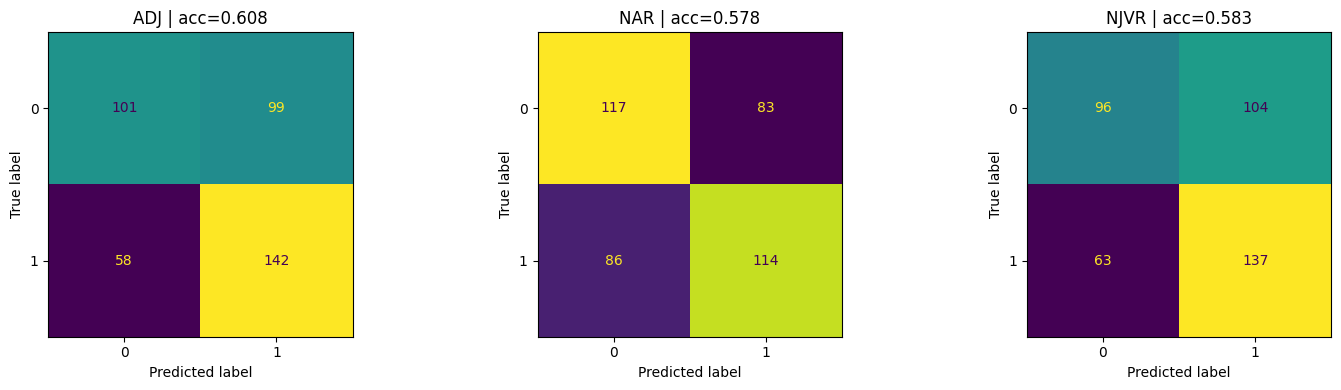

In [23]:
models_unsup = {
    "ADJ": pred_adj,
    "NAR": pred_nar,
    "NJVR": pred_njvr
}

rows = []
for name, pred in models_unsup.items():
    rows.append({"model": name, "accuracy": accuracy_score(y_val, pred)})

if "y_pred" in globals():
    rows.append({"model": "Regressió logística", "accuracy": accuracy_score(y_val, y_pred)})

df_acc = pd.DataFrame(rows).sort_values("accuracy", ascending=False).reset_index(drop=True)
print(df_acc)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, pred) in zip(axes, models_unsup.items()):
    cm = confusion_matrix(y_val, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(f"{name} | acc={accuracy_score(y_val, pred):.3f}")
plt.tight_layout()
plt.show()

Analitzant les 3 matrius podem veure que clarament **ningún** dels 3 models obté un millor resultat que l'algoritme supervisat (regressió logística).

En l'apartat *2.a*, la regressió logística només classificava erròniament 56 opinions, mentre que ara el model que **menys falla** és el model *ADJ* amb un total de **157 errors**, seguit del *NJVR* amb **167 errors** i finalment *NAR* amb **169 errors**.

En relació a l'accuracy, podem veure com es reflexa el que acabem de comentar: la regressió logística és manté com el millor model amb una accuracy de **0.86**, mentre que els models contruïts a l'apartat *2.b* obtenen una accuracy d'entre **0.61** i **0.57**.

Continuarem analitzant algunes mètriques addicionals:

In [24]:
for name, pred in models_unsup.items():
    print(name)
    print(classification_report(y_val, pred, digits=4, target_names=["Negatiu [0]", "Positiu [1]"]))

ADJ
              precision    recall  f1-score   support

 Negatiu [0]     0.6352    0.5050    0.5627       200
 Positiu [1]     0.5892    0.7100    0.6440       200

    accuracy                         0.6075       400
   macro avg     0.6122    0.6075    0.6033       400
weighted avg     0.6122    0.6075    0.6033       400

NAR
              precision    recall  f1-score   support

 Negatiu [0]     0.5764    0.5850    0.5806       200
 Positiu [1]     0.5787    0.5700    0.5743       200

    accuracy                         0.5775       400
   macro avg     0.5775    0.5775    0.5775       400
weighted avg     0.5775    0.5775    0.5775       400

NJVR
              precision    recall  f1-score   support

 Negatiu [0]     0.6038    0.4800    0.5348       200
 Positiu [1]     0.5685    0.6850    0.6213       200

    accuracy                         0.5825       400
   macro avg     0.5861    0.5825    0.5781       400
weighted avg     0.5861    0.5825    0.5781       400



Si ens basem en l'accuracy i la macro f1, podem veure que el **millor model** no supervisat és el *ADJ*, ja que presenta els valors més alts d'aquestes dues mètriques.

Tot i així, podem observar que el model *NAR* sembla el més equilibrat, ja que presenta els valors més semblants de precision i recall. Aquest fet indica que el model no presenta un **biaix clar** cap a ninguna de les dues classes.

En quant a *ADJ* i *NJVR*, aquests dos models tendeixen a **sobrepredir opinions positives**, i això es veu reflexat en valors **alts** de recall per la **classe positiva** i valors **més baixos** per la **classe negativa**.

Seguidament comprovarem la **distribució dels scores** per cadascun dels 3 models no supervisats:

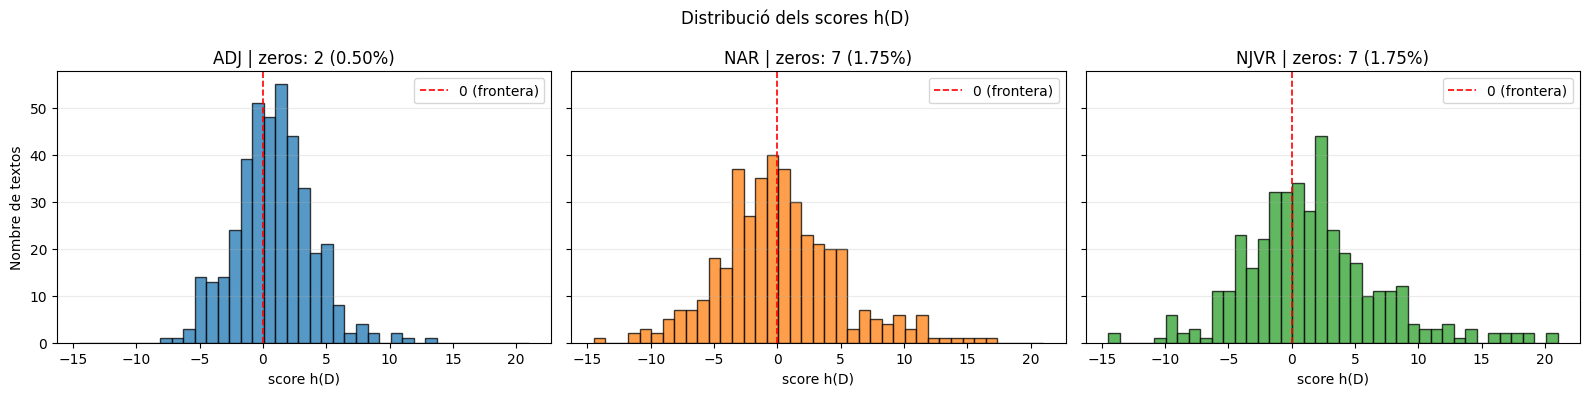

ADJ: zeros = 2/400 (0.50%)
NAR: zeros = 7/400 (1.75%)
NJVR: zeros = 7/400 (1.75%)


In [25]:
all_scores = np.concatenate([np.array(h_adj), np.array(h_nar), np.array(h_njvr)])
bins = np.linspace(all_scores.min(), all_scores.max(), 40)

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)

for ax, (name, hs, color) in zip(
    axes,
    [
        ("ADJ", h_adj, "tab:blue"),
        ("NAR", h_nar, "tab:orange"),
        ("NJVR", h_njvr, "tab:green"),
    ],
):
    hs = np.array(hs, dtype=float)
    zeros = np.sum(hs == 0)
    zero_pct = 100 * zeros / len(hs)
    ax.hist(hs, bins=bins, color=color, alpha=0.75, edgecolor="black")
    ax.axvline(0, color="red", linestyle="--", linewidth=1.2, label="0 (frontera)")
    ax.set_title(f"{name} | zeros: {zeros} ({zero_pct:.2f}%)")
    ax.set_xlabel("score h(D)")
    ax.grid(axis="y", alpha=0.25)
    ax.legend()

axes[0].set_ylabel("Nombre de textos")
plt.suptitle("Distribució dels scores h(D)")
plt.tight_layout()
plt.show()

for name, hs in [("ADJ", h_adj), ("NAR", h_nar), ("NJVR", h_njvr)]:
    hs = np.array(hs, dtype=float)
    zeros = np.sum(hs == 0)
    zero_pct = 100 * zeros / len(hs)
    print(f"{name}: zeros = {zeros}/{len(hs)} ({zero_pct:.2f}%)")

Podem observar que tant *ADJ* com *NJVR* presenten **més opinions positives que negatives**, ja que es veu clarament que hi ha una major proporció de la distribució a la **dreta de la frontera** (és a dir, presenten més scores positius que negatius). Això confirma el que hem observat a l'apartat anterior: tant *ADJ* com *NJVR* tendeixen a **sobrepredir opinions positives**. En el cas de *NAR*, la distribució que mostra és molt més **uniforme**, indicant que presenta un **nombre semblant** tant d'opinions positives com negatives. Això és coherent amb el fet que *NAR* no presenti un biaix clar cap a cap classe, tal i com hem vist abans.

Com a comentari addicional, tots tres models presenten una **proporció molt baixa de zeros**, indicant que no es gens comú que un score doni exactament 0.

Completarem el gràfic anterior visualitzant la **distribució de polaritat** per als scores:

  model  Positius  Negatius  Neutrals  %Positius  %Negatius  %Neutrals
0   ADJ       240       158         2      60.00      39.50       0.50
1   NAR       191       202         7      47.75      50.50       1.75
2  NJVR       238       155         7      59.50      38.75       1.75


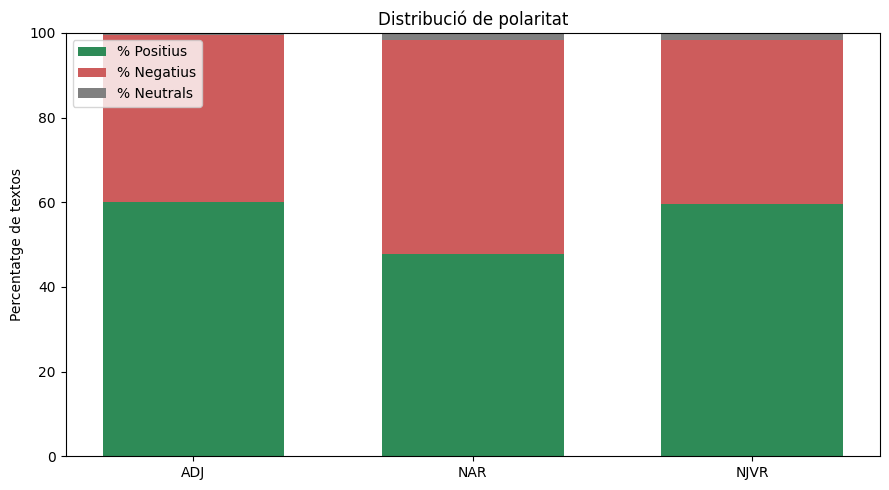

In [26]:
score_map = {
    "ADJ": h_adj,
    "NAR": h_nar,
    "NJVR": h_njvr
}

rows = []
for name, hs in score_map.items():
    hs = np.array(hs, dtype=float)
    pos = np.sum(hs > 0)
    neg = np.sum(hs < 0)
    neu = np.sum(hs == 0)
    total = len(hs)

    rows.append({
        "model": name,
        "Positius": pos,
        "Negatius": neg,
        "Neutrals": neu,
        "%Positius": 100 * pos / total,
        "%Negatius": 100 * neg / total,
        "%Neutrals": 100 * neu / total
    })

df_dist = pd.DataFrame(rows)
print(df_dist)

x = np.arange(len(df_dist))
w = 0.65

plt.figure(figsize=(9, 5))
plt.bar(x, df_dist["%Positius"], width=w, label="% Positius", color="seagreen")
plt.bar(x, df_dist["%Negatius"], width=w, bottom=df_dist["%Positius"], label="% Negatius", color="indianred")
plt.bar(x, df_dist["%Neutrals"], width=w, bottom=df_dist["%Positius"] + df_dist["%Negatius"], label="% Neutrals", color="gray")

plt.xticks(x, df_dist["model"])
plt.ylabel("Percentatge de textos")
plt.title("Distribució de polaritat")
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()

Tal i com hem vist abans, tant *ADJ* com *NJVR* presenten més opinions positives que negatives (en concret prop del **60%** en els dos casos), mentre que *NAR* presenta una distribució més equilibrada, amb un **50%** aproximadament tant per positius com per negatius.

Finalment, compararem els diferents **"acords"** entre tots els models, tant el model supervisat com els no supervisats:

In [27]:
preds_mat = np.vstack([pred_adj, pred_nar, pred_njvr]).T

full_agree = np.where(
    (preds_mat[:, 0] == preds_mat[:, 1]) &
    (preds_mat[:, 1] == preds_mat[:, 2])
)[0]

print(f"Acord total dels tres no supervisats: {len(full_agree)} / {len(y_val)}")
print(f"Desacord parcial: {len(y_val) - len(full_agree)}")
print(f"Acord total i correcte dels tres no supervisats (vs la y real: y_val): {(preds_mat[full_agree, 0] == np.array(y_val)[full_agree]).sum()} / {len(full_agree)}")

if "y_pred" in globals():
    y_sup = np.array(y_pred)

    print("\nCoincidencia de cada no supervisat amb la predicció del supervisat (y_pred):")
    print(f"ADJ  vs Regressió logística: {(np.array(pred_adj)  == y_sup).sum()} / {len(y_sup)}")
    print(f"NAR  vs Regressió logística: {(np.array(pred_nar)  == y_sup).sum()} / {len(y_sup)}")
    print(f"NJVR vs Regressió logística: {(np.array(pred_njvr) == y_sup).sum()} / {len(y_sup)}")

    agree_all4 = np.where(
        (preds_mat[:, 0] == preds_mat[:, 1]) &
        (preds_mat[:, 1] == preds_mat[:, 2]) &
        (preds_mat[:, 2] == y_sup)
    )[0]
    print(f"\nAcord total (3 no supervisats + supervisat): {len(agree_all4)} / {len(y_sup)}")

Acord total dels tres no supervisats: 242 / 400
Desacord parcial: 158
Acord total i correcte dels tres no supervisats (vs la y real: y_val): 154 / 242

Coincidencia de cada no supervisat amb la predicció del supervisat (y_pred):
ADJ  vs Regressió logística: 247 / 400
NAR  vs Regressió logística: 227 / 400
NJVR vs Regressió logística: 235 / 400

Acord total (3 no supervisats + supervisat): 153 / 400


Anem a veure la sortida pas a pas:
- En primer lloc, els tres models no supervisats coincideixen **més de la meitat dels cops** en si una opinió és positiva o negativa (en concret, amb **242** dels 400 exemples). Dit d'una a altra manera, hi han **158 casos** on al menys **un d'ells difereix**. A més, si mirem quants casos dels que coincideixen tots tres també coincideixen amb la etiqueta real, ens trobem amb un total de **154 opinions**. Aquest nombre es prou acceptable considerant que ningún d'aquests models supera a la regressió logística en termes d'accuracy.

- En segon lloc, si mirem quants cops coincideix cada model no supervisat amb la regressió logística ens trobem amb algo curiós: el model *NAR*, que hem vist que era el més equilibrat dels tres, és el que **menys coincideix amb la regressió logística** (**227** casos d'un total de 400), mentre que els altres dos presenten un nombre més elevat de coincidències (**247** pel cas de *ADJ* i **235** per *NJVR*). Això és interessant ja que, tal i com hem vist anteriorment, la regressió logística no semblava que estigués esbiaixada cap a cap classe, i ara hem descobert que coincideix més amb els models no supervisats *esbiaixats*.

- Finalment, podem veure que en **153** casos d'un total de 400, tant els 3 models no supervisats com la predicció de la regressió logística coincideixen.

Un cop fet l'analisi dels resultats passarem a **l'anàlisi dels errors**.

Començarem recordant el nombre de falsos positius i falsos negatius, i seguidament analitzarem les **paraules més freqüents** en els dos casos:

In [28]:
def error_breakdown(y_true, y_pred_local):
    fp = [i for i, (yt, yp) in enumerate(zip(y_true, y_pred_local)) if yt == 0 and yp == 1]
    fn = [i for i, (yt, yp) in enumerate(zip(y_true, y_pred_local)) if yt == 1 and yp == 0]
    return fp, fn

for name, pred in models_unsup.items():
    fp, fn = error_breakdown(y_val, pred)
    print(f"\n{name}")
    print(f"FP = {len(fp)} | FN = {len(fn)} | Errors totals = {len(fp) + len(fn)}")


ADJ
FP = 99 | FN = 58 | Errors totals = 157

NAR
FP = 83 | FN = 86 | Errors totals = 169

NJVR
FP = 104 | FN = 63 | Errors totals = 167


Tal i com hem vist en la matriu de confusió, el model *ADJ* presenta **157** errors, el model *NAR* **169** errors i el model *NJVR* **167** errors.

In [30]:
if "analyzer" not in globals():
    analyzer = vectorizer.build_analyzer()

def top_words_from_indices(texts, idxs, n=20):
    bag = []
    for i in idxs:
        bag.extend(analyzer(texts[i]))
    return Counter(bag).most_common(n)

for model_name, pred_sel in models_unsup.items():
    fp, fn = error_breakdown(y_val, pred_sel)
    print(f"MODEL: {model_name}")
    print(f"Top FP:")
    print(top_words_from_indices(val_texts, fp, n=20))
    print(f"Top FN:")
    print(top_words_from_indices(val_texts, fn, n=20))
    print()

MODEL: ADJ
Top FP:
[('film', 454), ('movie', 240), ('like', 195), ('good', 146), ('just', 145), ('time', 116), ('story', 104), ('characters', 100), ('character', 95), ('doesn', 94), ('make', 87), ('way', 84), ('new', 79), ('big', 79), ('director', 78), ('does', 78), ('action', 77), ('don', 76), ('plot', 75), ('people', 73)]
Top FN:
[('film', 281), ('movie', 142), ('like', 85), ('just', 80), ('character', 65), ('little', 62), ('time', 60), ('characters', 57), ('story', 56), ('life', 55), ('people', 49), ('does', 48), ('way', 46), ('films', 46), ('seen', 44), ('plot', 43), ('world', 43), ('know', 43), ('movies', 42), ('make', 41)]

MODEL: NAR
Top FP:
[('film', 347), ('movie', 202), ('like', 166), ('just', 118), ('good', 101), ('time', 93), ('characters', 86), ('story', 82), ('character', 81), ('make', 75), ('way', 74), ('plot', 70), ('does', 65), ('big', 64), ('really', 62), ('don', 61), ('new', 59), ('best', 59), ('little', 58), ('work', 58)]
Top FN:
[('film', 486), ('movie', 207), ('li

En general no hi ha molta diferència. Els 3 models no supervisats presenten *film*, *movie* i *like* com les tres paraules **més repetides** tant en falsos positius com en falsos negatius, i la resta de paraules també solen estar en els 3 models amb una freqüencia més o menys similar.

A més, si ho comparem amb les paraules més comunes de la regressió logística, podem veure que allà també tenim *film* i *movie* com les paraules més repetides.

Per tant, en aquest aspecte tots els models presentats tenen un **comportament similar**.

Per últim analitzarem la **longitud dels textos** tant en **encerts** com en opinions classificades de **forma errònia**:

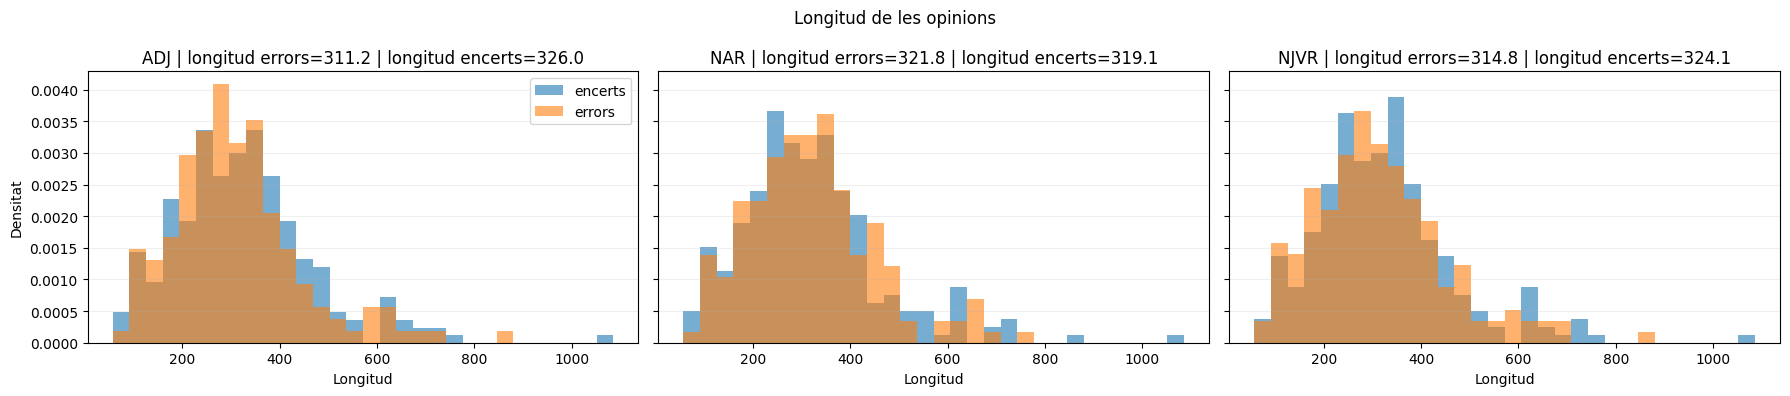

In [31]:
model_order = ["ADJ", "NAR", "NJVR"]

lengths_by_model = {}
for name in model_order:
    pred_sel = models_unsup[name]

    err_idx = [i for i, (yt, yp) in enumerate(zip(y_val, pred_sel)) if yt != yp]
    ok_idx = [i for i, (yt, yp) in enumerate(zip(y_val, pred_sel)) if yt == yp]

    len_err = [len(analyzer(val_texts[i])) for i in err_idx]
    len_ok = [len(analyzer(val_texts[i])) for i in ok_idx]

    lengths_by_model[name] = {"err": len_err, "ok": len_ok}

all_lengths = []
for name in model_order:
    all_lengths.extend(lengths_by_model[name]["err"])
    all_lengths.extend(lengths_by_model[name]["ok"])

bins = np.linspace(min(all_lengths), max(all_lengths), 31)

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)

for ax, name in zip(axes, model_order):
    len_err = lengths_by_model[name]["err"]
    len_ok = lengths_by_model[name]["ok"]

    mean_err = np.mean(len_err) if len(len_err) > 0 else 0.0
    mean_ok = np.mean(len_ok) if len(len_ok) > 0 else 0.0

    ax.hist(len_ok, bins=bins, alpha=0.6, label="encerts", density=True)
    ax.hist(len_err, bins=bins, alpha=0.6, label="errors", density=True)

    ax.set_title(f"{name} | longitud errors={mean_err:.1f} | longitud encerts={mean_ok:.1f}")
    ax.set_xlabel("Longitud")
    ax.grid(axis="y", alpha=0.2)

axes[0].set_ylabel("Densitat")
axes[0].legend()
plt.suptitle("Longitud de les opinions")
plt.tight_layout()
plt.show()

A diferència de la regressió logística, que solia classificar correctament les opinions llargues i fallar les curtes, els 3 models no supervisats presenten una distribució **força semblant** tant d'encerts com d'errors. 

En tots tres casos tenim una **longitud mitjana** d'encerts i errors força similar (a diferència de la regressió logistica, on teniem una longitud mitjana d'errors de **300** i una longitud mitjana d'encerts de **323** aproximadament). Tot i així, és interessant veure que tant *ADJ* com *NJVR* solen acertar, de mitjana, **textos més llargs** i fallar de **més curts** (tal i com passava amb la regressió logística), però amb *NAR* passa el contrari: els errors tenen de mitjana longituds **més llargues** que els encerts.

# Conclusió

En aquesta pràctica hem desenvolupat diversos models per la detecció d'opinions positives i negatives en ressenyes de pel·lícules, comparant dos enfocaments: un **model supervisat** i tres **models no supervisats**.

El model supervisat basat en **regressió logística** ha aconseguit una accuracy de **0.86**, classificant correctament **344 de 400 opinions** del conjunt de validació. Amb només **56 errors equilibrats** (28 falsos positius i 28 falsos negatius), el model ha demostrat no estar esbiaixat cap a cap classe.

A més, hem arribat a la conclusió que el model falla principalment en **textos curts**, on té menys context per a la decisió.

Els models no supervisats basats en **Lesk** + **SentiWordNet** han obtingut resultats significativament **pitjors**:
- **ADJ** (adjectius): 0.61 accuracy (157 errors)
- **NAR** (noms + adjectius + adverbis): 0.57 accuracy (169 errors)
- **NJVR** (noms + adjectius + verbs + adverbis): 0.58 accuracy (167 errors)

Tot i que *ADJ* i *NJVR* sobreprediuen opinions positives (excepte *NAR*, que és més equilibrat), els patrons d'error són **similars** a la regressió logística, amb paraules comunes com *film*, *movie* i *like*.

En definitiva, els models supervisats són **clarament preferibles** per a aquesta tasca, ja que ofereixen una millor combinació de precisió i equilibri de classes, on la **regressió logística** ha sigut l'opció més adequada.